# Bayesian Optimization with RF 

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import math
from tqdm.notebook import tqdm
import time

# Scikit-optimize imports
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# Scikit-learn for RF (though skopt handles it internally)
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import NotFittedError

# For plotting consistency if needed
plt.style.use('seaborn-v0_8-deep') # Or any preferred style


## Adjusted test func

In [33]:
def generate_multi_peak_gaussian_skopt(
    dim=2,
    n_peaks=5,
    amplitude_global=1.0,
    amplitude_local=0.6,
    alpha_global=50.0,
    alpha_local=30.0,
    shifts=None,
    min_peak_distance=0.5,
    noise=0.0,
    lower=-2.0,
    upper=2.0,
    random_state=None
):
    """
    Generates a multi-peak Gaussian function landscape suitable for skopt.

    Returns:
      - objective_func: A function f(x) where x is a list/array, returning a
                       scalar value to be *minimized*. (Negated for maximization).
      - space: A list of skopt.space.Real dimensions for the search space.
      - true_maximum: The approximate true maximum value (amplitude_global).
      - peak_info: Dictionary with details about the peaks.
      - func_name: A descriptive name for the function.
    """
    if amplitude_local >= amplitude_global:
        print("Warning: amplitude_local >= amplitude_global.")

    rng = np.random.default_rng(random_state)

    # Define search space for skopt
    space = [Real(lower, upper, name=f"x{i}") for i in range(dim)]

    # Determine peak locations
    if shifts is not None:
        shifts_arr = np.asarray(shifts)
        if shifts_arr.shape != (n_peaks, dim):
            raise ValueError(f"Shifts shape {shifts_arr.shape}, expected ({n_peaks}, {dim})")
        if np.any(shifts_arr < lower) or np.any(shifts_arr > upper):
             print(f"Warning: Some shifts outside bounds [{lower}, {upper}].")
    else:
        shifts_arr = rng.uniform(lower, upper, size=(n_peaks, dim))
        if n_peaks > 1:
            from scipy.spatial.distance import pdist
            distances = pdist(shifts_arr)
            min_dist_found = np.min(distances) if distances.size > 0 else np.inf
            if min_dist_found < min_peak_distance:
                print(f"Warning: Min peak distance ({min_dist_found:.3f}) < desired ({min_peak_distance:.3f}).")

    # Assign amplitudes and alphas
    amplitudes_arr = np.full(n_peaks, amplitude_local)
    alphas_arr = np.full(n_peaks, alpha_local)
    amplitudes_arr[0] = amplitude_global
    alphas_arr[0] = alpha_global

    peak_info = {
        'shifts': shifts_arr,
        'amplitudes': amplitudes_arr,
        'alphas': alphas_arr,
        'global_peak_index': 0,
        'optimal_params': shifts_arr[0].tolist() # Location of global max
    }

    # skopt minimizes, so we negate the function value for maximization
    # The function needs to accept a list/array x
    def objective_func(x):
        x_arr = np.asarray(x)
        total_value = 0.0
        for i in range(n_peaks):
            distance_sq = np.sum((x_arr - shifts_arr[i])**2)
            peak_val = amplitudes_arr[i] * np.exp(-alphas_arr[i] * distance_sq)
            total_value += peak_val

        if noise > 0:
            total_value += rng.normal(0, noise)
        return -total_value # Negate for minimization

    # Generate function name (similar to before)
    amp_g_str = f"{amplitude_global:.1f}".replace('.', 'p')
    amp_l_str = f"{amplitude_local:.1f}".replace('.', 'p')
    alpha_g_str = f"{alpha_global:.1f}".replace('.', 'p')
    alpha_l_str = f"{alpha_local:.1f}".replace('.', 'p')
    func_name = f"multiPeakGauss_d{dim}_p{n_peaks}_ag{amp_g_str}_al{amp_l_str}_alphag{alpha_g_str}_alphal{alpha_l_str}_n{noise:.2f}"
    func_name = re.sub(r'[^\w.\-]+', '', func_name)

    # The true maximum is approximately the global amplitude (without noise)
    true_maximum = amplitude_global

    return objective_func, space, true_maximum, peak_info, func_name



## Wrapper classes

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

class RFSurrogateWrapper(BaseEstimator, RegressorMixin):
    """
    A wrapper around sklearn's RandomForestRegressor that implements
    predict with return_std=True by calculating the standard deviation
    across tree predictions. Allows using a configurable RF within skopt.
    """
    def __init__(self, n_estimators=100, random_state=None, n_jobs=-1, **rf_kwargs):
        """
        Initializes the wrapper and the underlying RandomForestRegressor.

        Args:
            n_estimators (int): Number of trees for the internal RF.
            random_state (int): Random state for the internal RF.
            n_jobs (int): Number of jobs for the internal RF.
            **rf_kwargs: Other keyword arguments for RandomForestRegressor
                         (e.g., min_samples_leaf).
        """
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.rf_kwargs = rf_kwargs
        # Instantiate the underlying model immediately
        self.model = RandomForestRegressor(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=self.n_jobs,
            **self.rf_kwargs
        )

    def fit(self, X, y):
        """Fits the underlying RandomForestRegressor."""
        X, y = check_X_y(X, y, accept_sparse=False, y_numeric=True)
        self.model.fit(X, y)
        self.is_fitted_ = True
        return self

    def predict(self, X, return_std=False):
        """
        Predicts using the underlying RandomForestRegressor.

        If return_std=True, it calculates the mean and standard deviation
        across the predictions of individual trees in the forest.
        """
        X = check_array(X, accept_sparse=False)
        check_is_fitted(self, 'is_fitted_')

        if not return_std:
            # Standard prediction (mean across trees)
            return self.model.predict(X)
        else:
            # Predict with each tree individually
            # Ensure the underlying model has estimators_ attribute
            if not hasattr(self.model, 'estimators_') or not self.model.estimators_:
                 raise NotFittedError("The RandomForestRegressor model has not been fitted or has no estimators.")

            tree_predictions = np.array([tree.predict(X) for tree in self.model.estimators_])
            # tree_predictions shape: (n_estimators, n_samples)

            # Calculate mean and std dev across trees (axis=0)
            mean_prediction = np.mean(tree_predictions, axis=0)
            std_prediction = np.std(tree_predictions, axis=0)

            return mean_prediction, std_prediction

    # Optional: Implement set_params and get_params if needed for compatibility
    # with certain sklearn utilities, though likely not strictly necessary for skopt.
    def get_params(self, deep=True):
        params = self.model.get_params(deep=deep)
        # Add wrapper-specific params if any were defined beyond RF args
        params['n_estimators'] = self.n_estimators
        params['random_state'] = self.random_state
        params['n_jobs'] = self.n_jobs
        params.update(self.rf_kwargs)
        return params

    def set_params(self, **params):
        # Separate RF params from wrapper params if needed
        rf_params = {}
        wrapper_params = {}
        for key, value in params.items():
            if hasattr(self.model, key):
                 rf_params[key] = value
            else:
                 # Handle wrapper-specific params here if they existed
                 pass # e.g., self.some_wrapper_param = value

        # Update internal model - this might recreate the model
        self.model.set_params(**rf_params)
        # Update wrapper params if any
        for key, value in wrapper_params.items():
             setattr(self, key, value)

        # Re-apply params that might affect model recreation
        self.n_estimators = self.model.n_estimators
        self.random_state = self.model.random_state
        self.n_jobs = self.model.n_jobs
        # Update rf_kwargs based on what's left in rf_params? Careful here.
        # self.rf_kwargs = {k: v for k, v in rf_params.items() if k not in ['n_estimators', 'random_state', 'n_jobs']}

        return self



In [35]:
class SkoptOptimizer:
    """
    Base class for wrapping skopt optimization methods.
    Handles maximization by negating the objective function and results.
    """
    def __init__(self, objective_func, space, random_state=None, verbose=False):
        self.objective_func = objective_func # Assumes it's already set up for minimization
        self.space = space
        self.dim = len(space)
        self.random_state = random_state
        self.verbose = verbose

        # Results storage
        self.result_ = None
        self.x_iters_ = []
        self.func_vals_ = [] # Negated values (as returned by objective_func)
        self.best_func_vals_history_ = [] # Negated best values
        self.best_x_history_ = []
        self.current_best_val_negated_ = np.inf
        self.current_best_x_ = None
        self.total_time_ = 0

    def _callback(self, res):
        """Callback function to store iteration history."""
        self.x_iters_.append(res.x_iters[-1])
        current_val_negated = res.func_vals[-1]
        self.func_vals_.append(current_val_negated)

        # Update best found so far (minimization perspective)
        if current_val_negated < self.current_best_val_negated_:
            self.current_best_val_negated_ = current_val_negated
            self.current_best_x_ = res.x_iters[-1]

        self.best_func_vals_history_.append(self.current_best_val_negated_)
        self.best_x_history_.append(self.current_best_x_)

        if self.verbose:
            print(f"Iter: {len(self.x_iters_):>3} | "
                  f"Val: {-current_val_negated:>8.4f} | " # Display original scale
                  f"Best: {-self.current_best_val_negated_:>8.4f}", # Display original scale
                  end='\r')

    def optimize(self, n_calls=100, n_initial_points=10, base_estimator="GP", acq_func="EI", acq_optimizer="sampling", **kwargs):
        """
        Run the Bayesian Optimization.

        Args:
            n_calls (int): Total number of function evaluations.
            n_initial_points (int): Number of random evaluations before optimization.
            base_estimator (str): "GP", "RF", "ET", "GBRT".
            acq_func (str): Acquisition function (e.g., "EI", "LCB", "PI").
            acq_optimizer (str): Method to maximize acquisition ("sampling", "lbfgs").
            **kwargs: Additional arguments passed to skopt.gp_minimize.
        """
        self.x_iters_ = []
        self.func_vals_ = []
        self.best_func_vals_history_ = []
        self.best_x_history_ = []
        self.current_best_val_negated_ = np.inf
        self.current_best_x_ = None
        self.total_time_ = 0

        start_time = time.time()

        # Use gp_minimize for all base estimators for consistency
        self.result_ = gp_minimize(
            func=self.objective_func,
            dimensions=self.space,
            base_estimator=base_estimator,
            n_calls=n_calls,
            n_initial_points=n_initial_points,
            acq_func=acq_func,
            acq_optimizer=acq_optimizer,
            random_state=self.random_state,
            callback=self._callback,
            **kwargs
        )
        self.total_time_ = time.time() - start_time

        if self.verbose:
            print(f"\nOptimization finished in {self.total_time_:.2f} seconds.")
            print(f"Best value (maximized): {-self.result_.fun:.6f}")
            # print(f"Best parameters: {self.result_.x}") # Already printed by callback

        # Ensure history lists match n_calls
        if len(self.x_iters_) != n_calls:
             print(f"Warning: History length ({len(self.x_iters_)}) != n_calls ({n_calls}). Check skopt behavior.")

        return self.result_

    def get_maximization_results(self):
        """Returns results adjusted for maximization."""
        # Negate function values back to original scale
        original_func_vals = [-v for v in self.func_vals_]
        original_best_history = [-v for v in self.best_func_vals_history_]

        return {
            "x_iters": self.x_iters_,
            "func_vals": original_func_vals, # Values at each iteration (original scale)
            "best_func_history": original_best_history, # Best value found *up to* iter i
            "best_x_history": self.best_x_history_, # Best params found *up to* iter i
            "best_value": -self.result_.fun if self.result_ else None,
            "best_params": self.result_.x if self.result_ else None,
            "skopt_result": self.result_,
            "total_time": self.total_time_
        }

# We don't strictly need separate classes if SkoptOptimizer handles the
# base_estimator argument, but you could create them for clarity if desired:

# (Keep SkoptOptimizer base class as before)

class GPOptimizer(SkoptOptimizer):
    def optimize(self, n_calls=100, n_initial_points=10, acq_func="EI", acq_optimizer="sampling", **kwargs):
        # You could potentially pass GP kernel parameters via kwargs if needed
        # kernel = kwargs.pop('kernel', None) # Example
        # estimator = "GP" if kernel is None else GaussianProcessRegressor(kernel=kernel, ...)
        return super().optimize(n_calls=n_calls, n_initial_points=n_initial_points,
                                base_estimator="GP", # Use string for default GP
                                acq_func=acq_func,
                                acq_optimizer=acq_optimizer, **kwargs)

# (Keep SkoptOptimizer base class as before)
# (Keep GPOptimizer class as before)

# (Keep SkoptOptimizer base class)
# (Keep GPOptimizer class)

class RFOptimizer(SkoptOptimizer):
    def optimize(self, n_calls=100, n_initial_points=10, acq_func="EI", acq_optimizer="sampling",
                 # RF specific params for our wrapper
                 n_estimators=100, rf_random_state=None, **kwargs):
        """
        Optimize using the RFSurrogateWrapper.

        Args:
            n_estimators (int): Passed to RFSurrogateWrapper.
            rf_random_state (int): Passed to RFSurrogateWrapper.
                                   If None, uses self.random_state + 1.
            **kwargs: Additional arguments for skopt.gp_minimize (NOT for RF).
                      Can also include other RF params like min_samples_leaf
                      which will be passed to the wrapper's __init__.
        """
        # Determine random state for RF model reproducibility
        if rf_random_state is None:
            rf_model_state = self.random_state + 1 if self.random_state is not None else None
        else:
            rf_model_state = rf_random_state

        # Extract RF-specific kwargs meant for RandomForestRegressor
        # from the general kwargs passed to this method.
        rf_specific_kwargs = {k: v for k, v in kwargs.items() if k in RandomForestRegressor().get_params()}
        # Keep only gp_minimize specific kwargs
        gp_kwargs = {k: v for k, v in kwargs.items() if k not in rf_specific_kwargs}


        # Instantiate our WRAPPER
        rf_wrapper_estimator = RFSurrogateWrapper(
            n_estimators=n_estimators,
            random_state=rf_model_state,
            **rf_specific_kwargs # Pass other RF params like min_samples_leaf here
        )

        # Pass the wrapper INSTANCE to the base class optimize method
        return super().optimize(n_calls=n_calls, n_initial_points=n_initial_points,
                                base_estimator=rf_wrapper_estimator, # Pass the wrapper object
                                acq_func=acq_func,
                                acq_optimizer=acq_optimizer,
                                **gp_kwargs) # Pass only gp_minimize kwargs now


## Functions

In [36]:
def run_comparison(
    func_generator,
    dim=3,
    n_calls=50,
    n_initial_points=10,
    random_state=42,
    plot_results=True,
    verbose=False,
    func_params={}, # Pass params like n_peaks, noise etc. to generator
    gp_params={},   # Pass params specific to GP run (e.g., acq_func)
    rf_params={}    # Pass params specific to RF run
):
    """
    Runs BO with GP and RF surrogates and plots comparison.

    Args:
        func_generator: Function to generate objective, space, true_max, etc.
        dim (int): Dimensionality of the problem.
        n_calls (int): Total BO iterations.
        n_initial_points (int): Random exploration points.
        random_state (int): Seed for reproducibility.
        plot_results (bool): Whether to generate the comparison plot.
        verbose (bool): Print progress during optimization.
        func_params (dict): Args for the func_generator.
        gp_params (dict): Args for the GPOptimizer.optimize call.
        rf_params (dict): Args for the RFOptimizer.optimize call.

    Returns:
        dict: Contains results from both GP and RF runs.
    """
    # Generate the objective function and its properties
    objective_func, space, true_maximum, peak_info, func_name = func_generator(
        dim=dim, random_state=random_state, **func_params
    )
    print(f"--- Running Comparison on: {func_name} (Dim={dim}) ---")
    print(f"True Maximum Value (approx): {true_maximum:.6f}")
    print(f"Optimal Parameters (approx): {peak_info.get('optimal_params', 'N/A')}")
    print(f"Total Evals: {n_calls}, Initial Random: {n_initial_points}")

    # --- Run GP Optimization ---
    print("\n--- Starting GP Run ---")
    gp_optimizer = GPOptimizer(objective_func, space, random_state=random_state, verbose=verbose)
    gp_optimizer.optimize(n_calls=n_calls, n_initial_points=n_initial_points, **gp_params)
    gp_results = gp_optimizer.get_maximization_results()
    print(f"GP Best Value: {gp_results['best_value']:.6f} (Time: {gp_results['total_time']:.2f}s)")

    # --- Run RF Optimization ---
    print("\n--- Starting RF Run ---")
    # Use a different random state for RF's internal randomness if desired,
    # but keep the main BO sequence state the same for comparison start.
    rf_random_state = random_state + 1 if random_state is not None else None
    rf_optimizer = RFOptimizer(objective_func, space, random_state=random_state, verbose=verbose)
    # Pass RF specific params like n_estimators if needed inside rf_params
    # e.g., rf_params={'n_estimators': 100} -> passed via **rf_params
    rf_optimizer.optimize(n_calls=n_calls, n_initial_points=n_initial_points, **rf_params)
    rf_results = rf_optimizer.get_maximization_results()
    print(f"RF Best Value: {rf_results['best_value']:.6f} (Time: {rf_results['total_time']:.2f}s)")

    # --- Plotting ---
    if plot_results:
        print("\n--- Plotting Results ---")
        plot_comparison_results(
            gp_results, rf_results,
            true_maximum, peak_info,
            space, func_name, n_initial_points
        )

    return {"GP": gp_results, "RF": rf_results}



In [37]:
def plot_comparison_results(
    gp_results, rf_results,
    true_maximum, peak_info,
    space, func_name, n_initial_points
):
    """
    Generates a 2x2 plot comparing GP and RF optimization runs.
    """
    dim = len(space)
    param_names = [s.name for s in space]
    optimal_params = peak_info.get('optimal_params', [None]*dim)
    n_calls = len(gp_results['x_iters']) # Assume same length for both

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex='col')
    fig.suptitle(f"Bayesian Optimization Comparison: GP vs RF", fontsize=16, y=1.02)

    iterations = np.arange(1, n_calls + 1)
    colors = plt.cm.viridis(np.linspace(0, 0.85, dim)) # Colors for dimensions

    # --- Top Row: Parameter Evolution ---
    ax_gp_params = axs[0, 0]
    ax_rf_params = axs[0, 1]

    for d_idx in range(dim):
        gp_params_d = [x[d_idx] for x in gp_results['x_iters']]
        rf_params_d = [x[d_idx] for x in rf_results['x_iters']]

        ax_gp_params.scatter(iterations, gp_params_d, label=param_names[d_idx], s=10, alpha=0.7, c=[colors[d_idx]])
        ax_rf_params.scatter(iterations, rf_params_d, label=param_names[d_idx], s=10, alpha=0.7, c=[colors[d_idx]])

        # Plot optimal parameter line if available
        if optimal_params[d_idx] is not None:
            ax_gp_params.axhline(optimal_params[d_idx], color=colors[d_idx], linestyle='--', linewidth=1.5, alpha=0.8)
            ax_rf_params.axhline(optimal_params[d_idx], color=colors[d_idx], linestyle='--', linewidth=1.5, alpha=0.8)

    # Add vertical line for switch from random to acquisition
    ax_gp_params.axvline(n_initial_points + 0.5, color='black', linestyle=':', linewidth=1.5, label='Acq. Start')
    ax_rf_params.axvline(n_initial_points + 0.5, color='black', linestyle=':', linewidth=1.5, label='Acq. Start')

    ax_gp_params.set_title('GP Surrogate: Parameter Evolution')
    ax_gp_params.set_ylabel('Parameter Value')
    ax_gp_params.legend(fontsize='small', loc='best')
    ax_gp_params.grid(True, linestyle=':')

    ax_rf_params.set_title('RF Surrogate: Parameter Evolution')
    ax_rf_params.set_ylabel('Parameter Value')
    ax_rf_params.legend(fontsize='small', loc='best')
    ax_rf_params.grid(True, linestyle=':')

    # --- Bottom Row: Performance (% Difference from Max) ---
    ax_gp_perf = axs[1, 0]
    ax_rf_perf = axs[1, 1]

    def calculate_perc_diff(history, true_max):
        diffs = []
        # Use absolute difference if true_max is very small or zero
        use_abs = abs(true_max) < 1e-9
        for val in history:
            if use_abs:
                diff = abs(true_max - val)
            else:
                # Calculate difference relative to true max, ensure non-negative %
                diff = max(0, true_max - val) / abs(true_max) * 100
            diffs.append(diff)
        return diffs

    gp_perf = calculate_perc_diff(gp_results['best_func_history'], true_maximum)
    rf_perf = calculate_perc_diff(rf_results['best_func_history'], true_maximum)

    ax_gp_perf.plot(iterations, gp_perf, marker='.', linestyle='-', color='red', label='GP Performance')
    ax_rf_perf.plot(iterations, rf_perf, marker='.', linestyle='-', color='blue', label='RF Performance')

    # Add horizontal line at 0% difference
    ax_gp_perf.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax_rf_perf.axhline(0, color='black', linestyle='--', linewidth=1.5)

    # Add vertical line for switch
    ax_gp_perf.axvline(n_initial_points + 0.5, color='black', linestyle=':', linewidth=1.5)
    ax_rf_perf.axvline(n_initial_points + 0.5, color='black', linestyle=':', linewidth=1.5)


    ax_gp_perf.set_title('GP Surrogate: Performance')
    ax_gp_perf.set_xlabel('Iteration')
    ax_gp_perf.set_ylabel('% Difference from True Max')
    ax_gp_perf.set_ylim(bottom=-5) # Allow seeing slightly below 0
    ax_gp_perf.grid(True, linestyle=':')

    ax_rf_perf.set_title('RF Surrogate: Performance')
    ax_rf_perf.set_xlabel('Iteration')
    ax_rf_perf.set_ylabel('% Difference from True Max')
    ax_rf_perf.set_ylim(bottom=-5)
    ax_rf_perf.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout
    plt.show()



## Experiments

## 3D

--- Running Comparison on: multiPeakGauss_d3_p4_ag1p0_al0p7_alphag2p0_alphal1p0_n0.00 (Dim=3) ---
True Maximum Value (approx): 1.000000
Optimal Parameters (approx): [0.7294074529925738, -1.7847159247911093, -1.1185605089095545]
Total Evals: 75, Initial Random: 15

--- Starting GP Run ---
GP Best Value: 1.006753 (Time: 7.25s)

--- Starting RF Run ---
RF Best Value: 1.008478 (Time: 4.48s)

--- Plotting Results ---


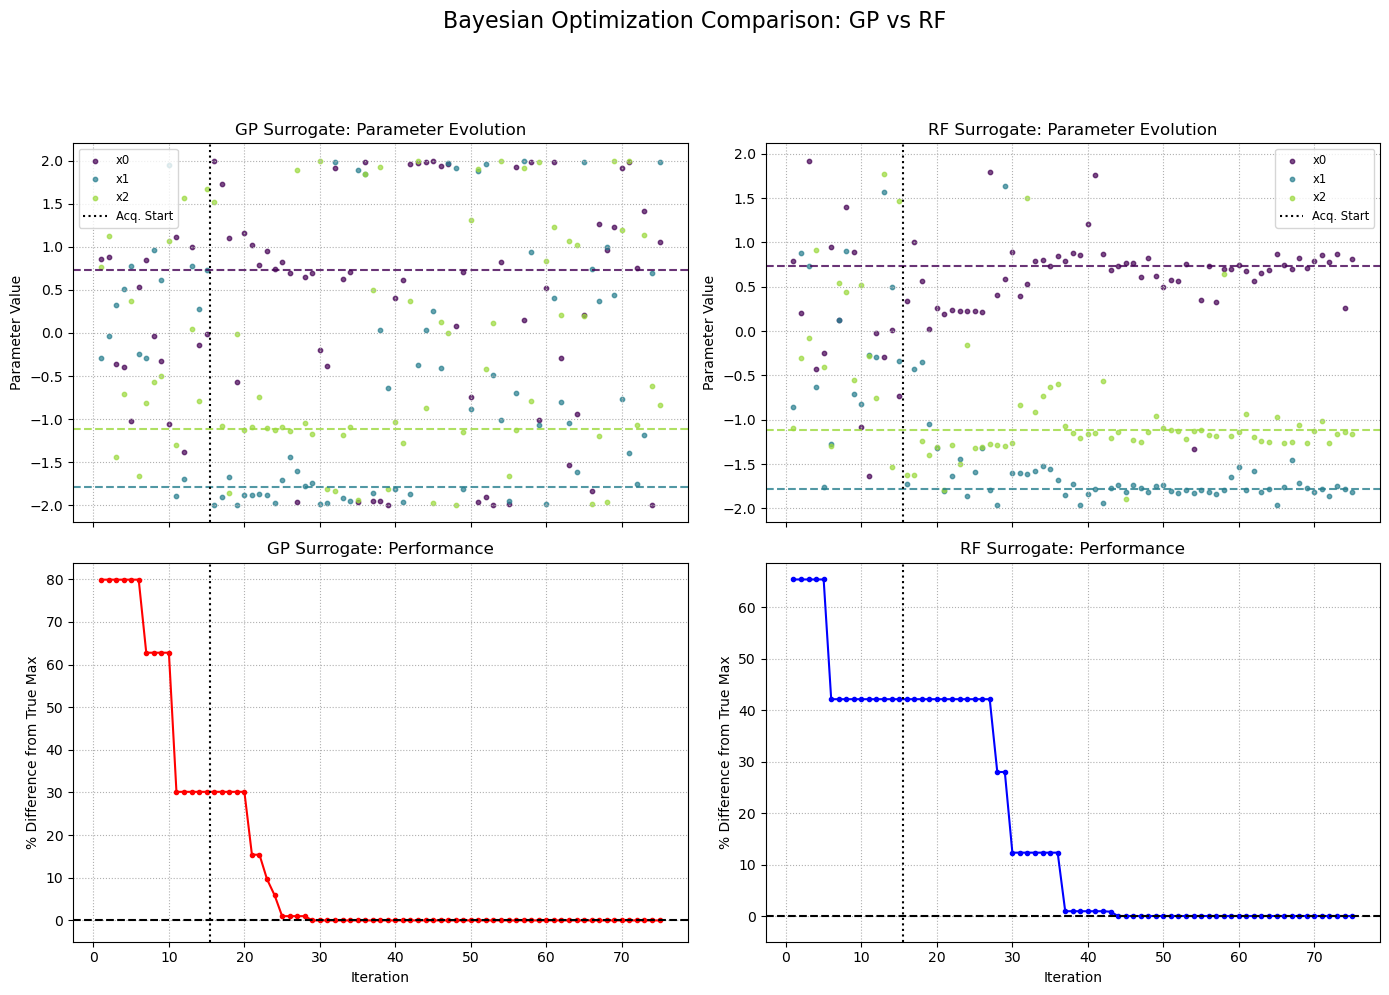

In [48]:
# --- Configuration ---
DIMENSIONS = 3
N_CALLS = 75
N_INITIAL_POINTS = 15
RANDOM_STATE = 123
ACQ_FUNC = 'EI'

func_params = {
    'n_peaks': 4, 'amplitude_local': 0.7, 'alpha_global': 2.0,
    'alpha_local': 1.0, 'noise': 0.0001, 'lower': -2.0, 'upper': 2.0
}

# Parameters specific to the optimization runs
gp_params = {'acq_func': ACQ_FUNC}

# rf_params contains arguments for RFOptimizer.optimize,
# which will be used to configure RFSurrogateWrapper.
rf_params = {
    'acq_func': ACQ_FUNC,
    'n_estimators': 100,
    'min_samples_leaf': 3, # Example: Pass other RF params here
    # 'rf_random_state': RANDOM_STATE + 1 # Optional explicit state
}

# --- Run the Comparison ---
comparison_results = run_comparison(
    func_generator=generate_multi_peak_gaussian_skopt,
    dim=DIMENSIONS,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_POINTS,
    random_state=RANDOM_STATE,
    plot_results=True,
    verbose=False,
    func_params=func_params,
    gp_params=gp_params,
    rf_params=rf_params
)


## 5D

--- Running Comparison on: multiPeakGauss_d5_p4_ag1p0_al0p7_alphag2p0_alphal1p0_n0.00 (Dim=5) ---
True Maximum Value (approx): 1.000000
Optimal Parameters (approx): [0.7294074529925738, -1.7847159247911093, -1.1185605089095545, -1.2625127572053212, -1.2963763956598786]
Total Evals: 100, Initial Random: 25

--- Starting GP Run ---
GP Best Value: 0.939318 (Time: 20.03s)

--- Starting RF Run ---
RF Best Value: 0.728881 (Time: 6.03s)

--- Plotting Results ---


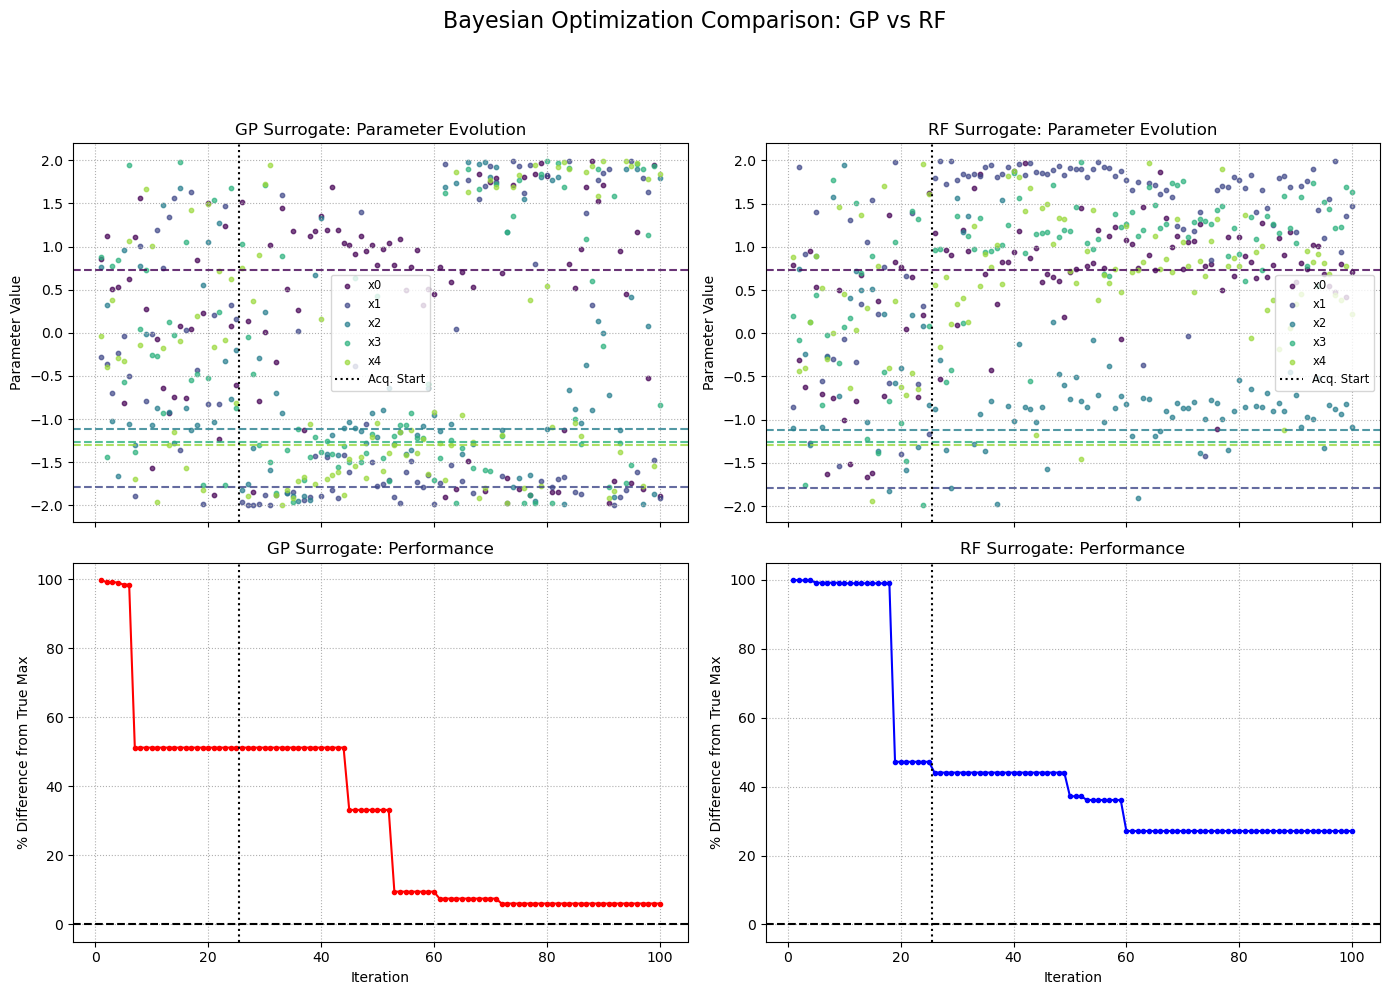

In [46]:
# --- Configuration ---
DIMENSIONS = 5
N_CALLS = 100
N_INITIAL_POINTS = 25
RANDOM_STATE = 123
ACQ_FUNC = 'EI'

func_params = {
    'n_peaks': 4, 'amplitude_local': 0.7, 'alpha_global': 2.0,
    'alpha_local': 1.0, 'noise': 0.0001, 'lower': -2.0, 'upper': 2.0
}

# Parameters specific to the optimization runs
gp_params = {'acq_func': ACQ_FUNC}

# rf_params contains arguments for RFOptimizer.optimize,
# which will be used to configure RFSurrogateWrapper.
rf_params = {
    'acq_func': ACQ_FUNC,
    'n_estimators': 100,
    'min_samples_leaf': 3, # Example: Pass other RF params here
    # 'rf_random_state': RANDOM_STATE + 1 # Optional explicit state
}

# --- Run the Comparison ---
comparison_results = run_comparison(
    func_generator=generate_multi_peak_gaussian_skopt,
    dim=DIMENSIONS,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_POINTS,
    random_state=RANDOM_STATE,
    plot_results=True,
    verbose=False,
    func_params=func_params,
    gp_params=gp_params,
    rf_params=rf_params
)


## 7D

--- Running Comparison on: multiPeakGauss_d7_p4_ag1p0_al0p7_alphag2p0_alphal1p0_n0.00 (Dim=7) ---
True Maximum Value (approx): 1.000000
Optimal Parameters (approx): [0.7294074529925738, -1.7847159247911093, -1.1185605089095545, -1.2625127572053212, -1.2963763956598786, 1.2483780266230946, 1.6933799921082255]
Total Evals: 500, Initial Random: 35

--- Starting GP Run ---
GP Best Value: 0.654373 (Time: 1657.27s)

--- Starting RF Run ---
RF Best Value: 0.498140 (Time: 43.79s)

--- Plotting Results ---


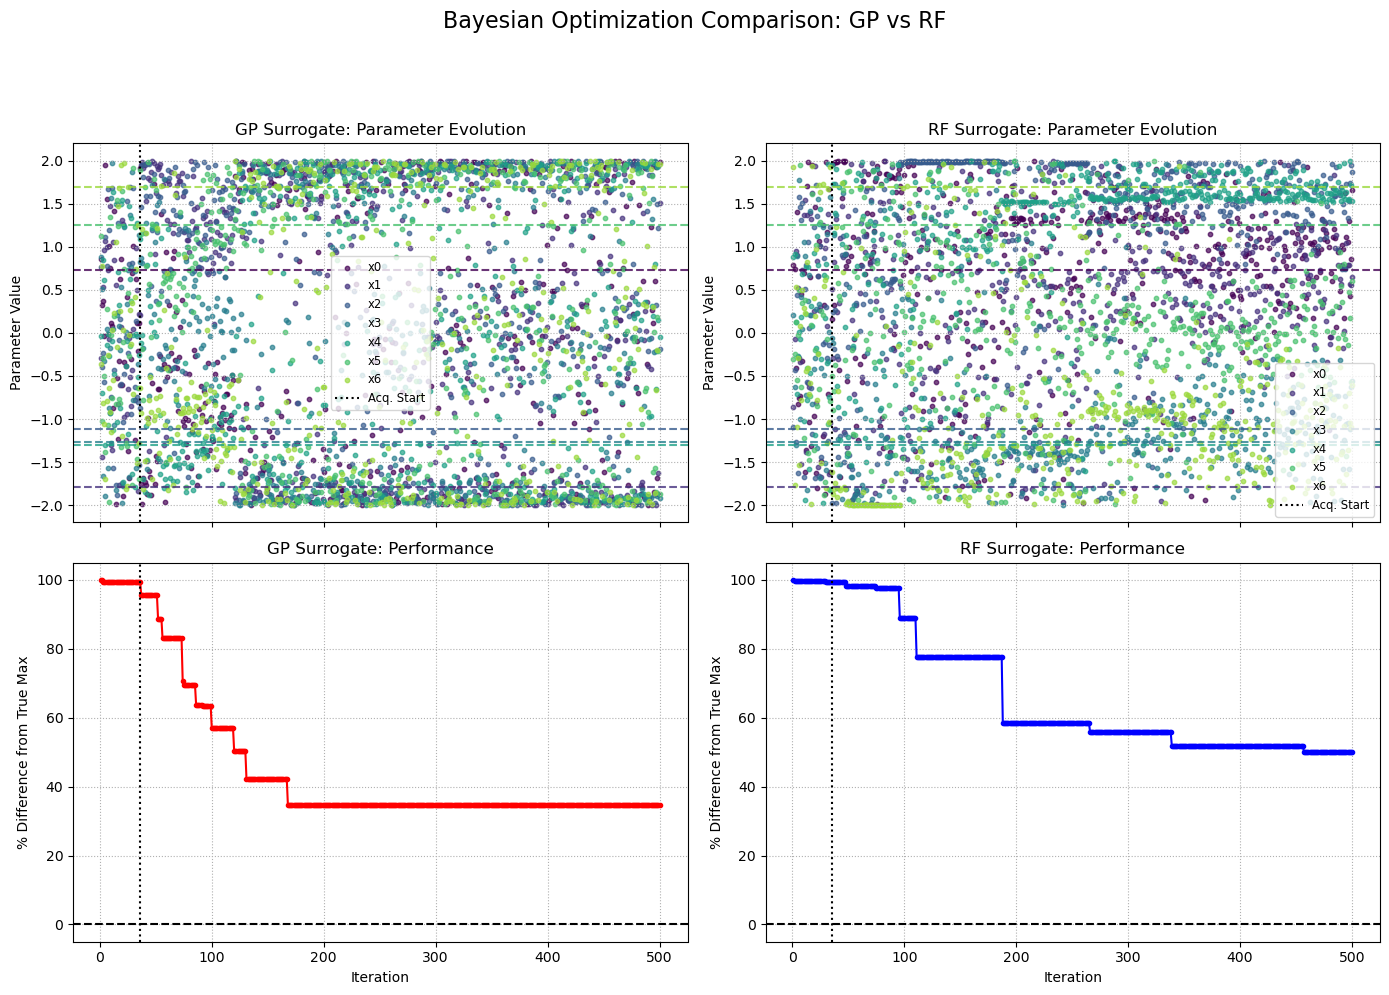

In [49]:
# --- Configuration ---
DIMENSIONS = 7
N_CALLS = 500
N_INITIAL_POINTS = 35
RANDOM_STATE = 123
ACQ_FUNC = 'EI'

func_params = {
    'n_peaks': 4, 'amplitude_local': 0.7, 'alpha_global': 2.0,
    'alpha_local': 1.0, 'noise': 0.0001, 'lower': -2.0, 'upper': 2.0
}

# Parameters specific to the optimization runs
gp_params = {'acq_func': ACQ_FUNC}

# rf_params contains arguments for RFOptimizer.optimize,
# which will be used to configure RFSurrogateWrapper.
rf_params = {
    'acq_func': ACQ_FUNC,
    'n_estimators': 100,
    'min_samples_leaf': 3, # Example: Pass other RF params here
    # 'rf_random_state': RANDOM_STATE + 1 # Optional explicit state
}

# --- Run the Comparison ---
comparison_results = run_comparison(
    func_generator=generate_multi_peak_gaussian_skopt,
    dim=DIMENSIONS,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_POINTS,
    random_state=RANDOM_STATE,
    plot_results=True,
    verbose=False,
    func_params=func_params,
    gp_params=gp_params,
    rf_params=rf_params
)
